In [30]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [31]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [32]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [33]:
llm.invoke("How are you").content

"I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?"

In [34]:
from typing import TypedDict, Annotated,List,Union
import operator

In [35]:
from langchain_core.messages import AnyMessage, HumanMessage,AIMessage

In [36]:
class AgentState(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

In [37]:
def llm_call(state:AgentState)->AgentState:
    '''Call the LLM using conversation messages and append the AI message'''
    response = llm.invoke(state['messages'])
    state["messages"].append(AIMessage(content=response.content))
    return state

In [38]:
def token_counter(state: AgentState)-> AgentState:
    '''Count the number of token generated by the AI response'''
    last_message = state['messages'][-1]
    text = last_message.content
    text_length = len(text.split())
    summary = f"Total number of tokens in the generated answer is {text_length}"
    state["messages"].append(AIMessage(content=summary))
    return state

In [39]:
graph = StateGraph(AgentState)
graph.add_node("llm_call",llm_call)
graph.add_node("token_counter",token_counter)

In [40]:
graph.set_entry_point("llm_call")
graph.add_edge("llm_call","token_counter")
graph.set_finish_point("token_counter")
app = graph.compile()

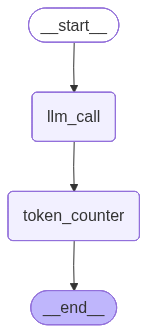

In [41]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [42]:
result = app.invoke({"messages": [HumanMessage(content="Hello how are you")]})   

In [43]:
result

{'messages': [HumanMessage(content='Hello how are you', additional_kwargs={}, response_metadata={}, id='55682230-8b0a-4ff9-9d6c-99ac9aea77e4'),
  AIMessage(content="Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={}, response_metadata={}, id='843b868c-ef5a-461c-bbfb-a4cdc831c32d', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Total number of tokens in the generated answer is 24', additional_kwargs={}, response_metadata={}, id='02f73bb2-a82a-4790-8109-7c37bbb64e9b', tool_calls=[], invalid_tool_calls=[])]}

In [44]:
res = app.invoke({"messages": [HumanMessage(content="What is the plan for tomorrow")]})   

In [45]:
res

{'messages': [HumanMessage(content='What is the plan for tomorrow', additional_kwargs={}, response_metadata={}, id='7f4c70e4-42fa-48c1-a52b-cedbda7b6395'),
  AIMessage(content="I don't have access to real-time information or personal schedules, so I can't provide specific plans for tomorrow. However, if you have something in mind or need help organizing your day, feel free to share, and I can help you brainstorm ideas or create a plan!", additional_kwargs={}, response_metadata={}, id='2e87d811-3322-4223-aa23-18f0185f8a58', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='Total number of tokens in the generated answer is 46', additional_kwargs={}, response_metadata={}, id='0f53855d-513f-43ee-88fc-71af7661277a', tool_calls=[], invalid_tool_calls=[])]}

In [46]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [47]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [48]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [49]:
wiki_tool.invoke({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code (vibe coding) or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased significantly s'

In [50]:
from langchain_community.tools.tavily_search import TavilySearchResults
import os
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [51]:
tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

/var/folders/88/p2ppv1mj0d1078cjs408f6ch0000gn/T/ipykernel_19583/1291469283.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [52]:
tavily_tool.invoke({"query":"How is the job market for fresher graduate in 2026"})


[{'title': 'Graduates face tough job market in 2026',
  'url': 'https://www.youtube.com/watch?v=pRLA0iaayaw',
  'content': "Trying to figure out where it's at. Esteban Perez is a newly minted college graduate. He now has a degree in cybersecurity from MSU Denver and is ready to tackle the future. It is rewarding, it's exciting, it's a little bit intimidating. Intimidating? Uh the job market. There's not as many entry-level positions as there were 3 years ago when I started going to school. By all accounts, jobs in what some term a low hire, low fire economy are hard to come by these days. The college class of 2026, the Wall Street Journal wrote, is entering one of the most nerve-racking job markets in recent memory. It's a competitive market. Adrian Martinez helps MSU Denver students plan for future careers, but she also does hiring. We're receiving hundreds of applicants for near entry-level positions from [...] # Graduates face tough job market in 2026\n## CGTN America\n892000 subscr

In [53]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [54]:
search.invoke("What is the latest update about on iphone18 release")

"iPhone 18 and iPhone 18e. The lower-cost iPhone models won't be Apple's focus in the fall of 2026, and we know little about them other than they are in development. About Press Copyright Contact us Creators Advertise Developers Terms Privacy Policy & Safety How... Get the latest updates on Apple's upcoming smartphone lineup! #iPhone18 #AppleNews. iPhone 18 release date, iPhone 18 features, Apple 2027 smartphone, upcoming iPhone models, new iPhone announcements, Apple technology news, iPhone lineup details... Here’s the expected iOS 26.3 release date. iOS 26.3 launch expected in late January.So when considering the launch date for iOS 26.3, all we have to do is look at Apple’s last few years of history. Here are release dates for the last several iOS x.3 updates Wondering how to change wallpapers on iPhone? Here are a few easy steps to change or delete your wallpaper, plus a look at upcoming wallpaper features in iOS 18."

YOUTUBE SEARCH TOOL

In [55]:
from langchain_community.tools import YouTubeSearchTool

In [56]:
tool = YouTubeSearchTool()

In [57]:
tool.name

'youtube_search'

In [58]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [59]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=bjkjaqUZl4E&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=LZzq1zSL1bs&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [60]:
from langchain_community.tools import tool

In [61]:
@tool
def multiply(a:int,b:int) -> int:
    '''Multiply 2 given numbers '''
    return a*b

In [62]:
multiply.invoke({"a":20,"b":30})

600

In [63]:
@tool
def get_word_length(word:str) -> int:
    '''Get the count of the no of words in the given string'''
    res = len(word.split())
    return res

In [64]:
get_word_length.invoke({"word":"Lorem Ipsum is simply dummy text of the printing and typesetting industry. Lorem Ipsum has been the industry's standard dummy text ever since 1966, when designers at Letraset and James Mosley, the librarian at St Bride Printing Library in London, took a 1914 Cicero translation and scrambled it to make dummy text for Letraset's Body Type sheets. It has survived not only many decades, but also the leap into electronic typesetting, remaining essentially unchanged. It was popularised thanks to these sheets and more recently with desktop publishing software like Aldus PageMaker and Microsoft Word including versions of Lorem Ipsum."})

99

YAHOO FINANCE

In [65]:
import yfinance as yf

In [66]:
@tool
def get_stock_price(ticker:str)-> str:
    '''This is a tool to get the stock price using yfinance'''
    try:
        stock = yf.Ticker(ticker)
        data = stock.history(period='1d')

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol"
        else:
            latest_close = data['Close'].iloc[-1]

            # Detect currency
            currency = stock.info.get("currency","")
            symbol_map ={
                "INR": "₹",
                "USD": "$",
                "EUR": "€"
            }

            symbol = symbol_map.get(currency,"")
            currency_text = currency if currency else ""

            if symbol:
                return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
            else:
                return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."
    except Exception as e:
        return f"An error occured while fetching stock data: {str(e)}"


In [67]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $331.16.'

In [68]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹808.30.'

In [75]:
tools = [get_stock_price,get_word_length,multiply,tavily_tool]

In [76]:
llm_with_tools = llm.bind_tools(tools)

In [72]:
result = llm_with_tools.invoke("What is the stock price of the TCS.NS")

In [74]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_Xn5d8xzZ6JxULG8TzSeAeH7i',
  'type': 'tool_call'}]

In [77]:
result = llm_with_tools.invoke("What is in the latest Indian Union budget report of 2026?")

In [78]:
result.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest Indian Union budget report 2026'},
  'id': 'call_LNPwbbu8E4PnItxDAV23YyCv',
  'type': 'tool_call'}]

In [82]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, MessagesState, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [81]:
def function_1(state:MessagesState):
    pass

In [83]:
tools

[StructuredTool(name='get_stock_price', description='This is a tool to get the stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x12e0d3600>),
 StructuredTool(name='get_word_length', description='Get the count of the no of words in the given string', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x12e0d0cc0>),
 StructuredTool(name='multiply', description='Multiply 2 given numbers', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x12e0d1080>),
 TavilySearchResults(api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********')))]

In [84]:
function_2 = ToolNode(tools)

In [89]:
graph = StateGraph(MessagesState)
graph.add_node("llm",function_1)
graph.add_node("tools", function_2)
graph.add_edge(START,"llm")
graph.add_edge("tools","llm")
graph.add_conditional_edges(
    "llm",
    tools_condition
)
app = graph.compile()

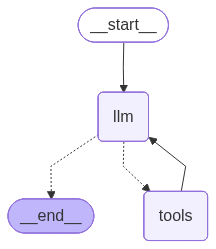

In [90]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))